#### 1- Data preparation

In [127]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

def generate_data():
    num_classes = 10
    samples_per_class = 2000
    img_size = 14
    feature_dim = img_size * img_size
    variance = 50
    
    means = np.random.uniform(low=-5, high=5, size=(num_classes, feature_dim))
    
    all_images = []
    all_labels = []
    
    for class_id in range(num_classes):
        class_mean = means[class_id]
        cov = np.eye(feature_dim) * variance
        class_samples = np.random.multivariate_normal(class_mean, cov, samples_per_class)
        class_samples = class_samples.reshape(samples_per_class, img_size, img_size)
        
        all_images.append(class_samples)
        all_labels.append(np.full(samples_per_class, class_id + 1))
    
    X = np.vstack(all_images)
    y = np.hstack(all_labels)
    
    return X, y

def split_data(X, y):
    X_flat = X.reshape(X.shape[0], -1)
    X_train, X_test, y_train, y_test = train_test_split(
        X_flat, y, test_size=0.2, stratify=y, random_state = 1
    )
    return X_train, X_test, y_train, y_test

def to_torch_data(X_train, X_test, y_train, y_test):
    X_train_tensor = torch.FloatTensor(X_train).reshape(-1, 1, 14, 14)
    X_test_tensor = torch.FloatTensor(X_test).reshape(-1, 1, 14, 14)
    y_train_tensor = torch.LongTensor(y_train - 1)
    y_test_tensor = torch.LongTensor(y_test - 1)
    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor

class SyntheticDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

def create_loaders(X_train, X_test, y_train, y_test, batch_size=64):
    train_dataset = SyntheticDataset(X_train, y_train)
    test_dataset = SyntheticDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader, train_dataset, test_dataset

def get_data(batch_size=64):
    X, y = generate_data()
    X_train, X_test, y_train, y_test = split_data(X, y)
    X_train, X_test, y_train, y_test = to_torch_data(X_train, X_test, y_train, y_test)
    train_loader, test_loader, train_dataset, test_dataset = create_loaders(
        X_train, X_test, y_train, y_test, batch_size
    )
    return train_loader, test_loader, train_dataset, test_dataset

In [128]:
import matplotlib.pyplot as plt

def report_and_visualize(dataset, num_samples=10):
    images = dataset.images.numpy()
    labels = dataset.labels.numpy()
    
    print(f'num saples: {len(dataset)}')
    print(f'shape: {images.shape[1:]}')
    print(f'mean: {images.mean():.2f}')
    print(f'std: {images.std():.2f}')
    
    unique, counts = np.unique(labels, return_counts=True)
    print('\n class dists:')
    for c, cnt in zip(unique, counts):
        print(f'  class {c+1}: {cnt} sample ({cnt/len(dataset)*100:.1f}%)')
    
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i in range(10):
        row, col = i // 5, i % 5
        class_mask = labels == i
        if class_mask.any():
            sample_idx = np.where(class_mask)[0][0]
            axes[row, col].imshow(images[sample_idx, 0], cmap='gray')
        axes[row, col].set_title(f'class {i+1}')
        axes[row, col].axis('off')
    
    plt.suptitle('sample ')
    plt.tight_layout()
    plt.show()

train
num saples: 16000
shape: (1, 14, 14)
mean: -0.06
std: 7.64

 class dists:
  class 1: 1600 sample (10.0%)
  class 2: 1600 sample (10.0%)
  class 3: 1600 sample (10.0%)
  class 4: 1600 sample (10.0%)
  class 5: 1600 sample (10.0%)
  class 6: 1600 sample (10.0%)
  class 7: 1600 sample (10.0%)
  class 8: 1600 sample (10.0%)
  class 9: 1600 sample (10.0%)
  class 10: 1600 sample (10.0%)


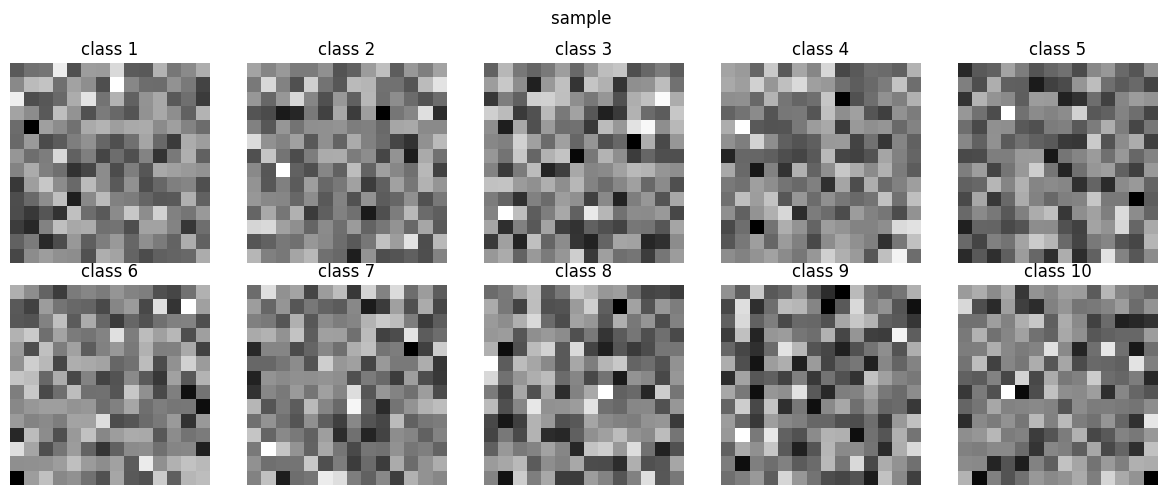

test
num saples: 4000
shape: (1, 14, 14)
mean: -0.06
std: 7.62

 class dists:
  class 1: 400 sample (10.0%)
  class 2: 400 sample (10.0%)
  class 3: 400 sample (10.0%)
  class 4: 400 sample (10.0%)
  class 5: 400 sample (10.0%)
  class 6: 400 sample (10.0%)
  class 7: 400 sample (10.0%)
  class 8: 400 sample (10.0%)
  class 9: 400 sample (10.0%)
  class 10: 400 sample (10.0%)


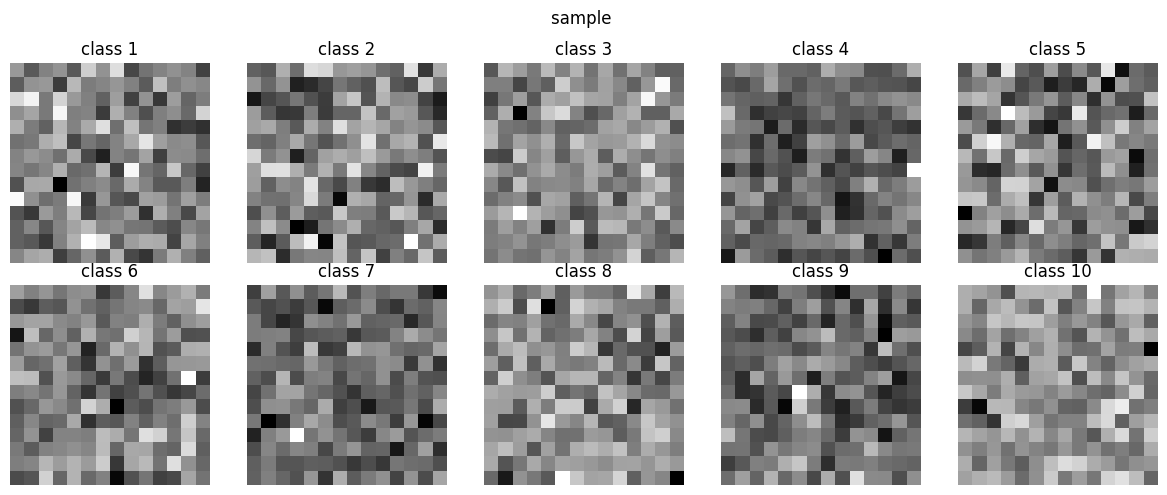

In [129]:
batch_size = 64
train_loader, test_loader, train_dataset, test_dataset = get_data(batch_size)

print('train')
report_and_visualize(train_dataset)

print('test')
report_and_visualize(test_dataset)

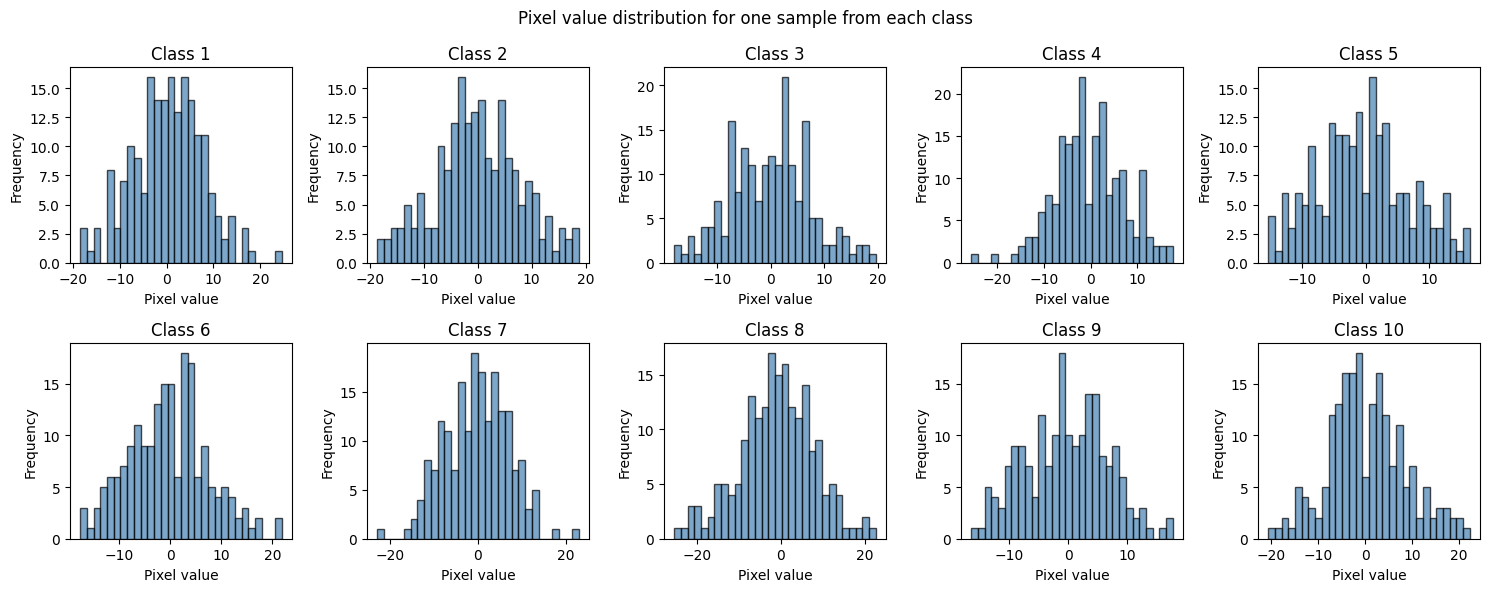

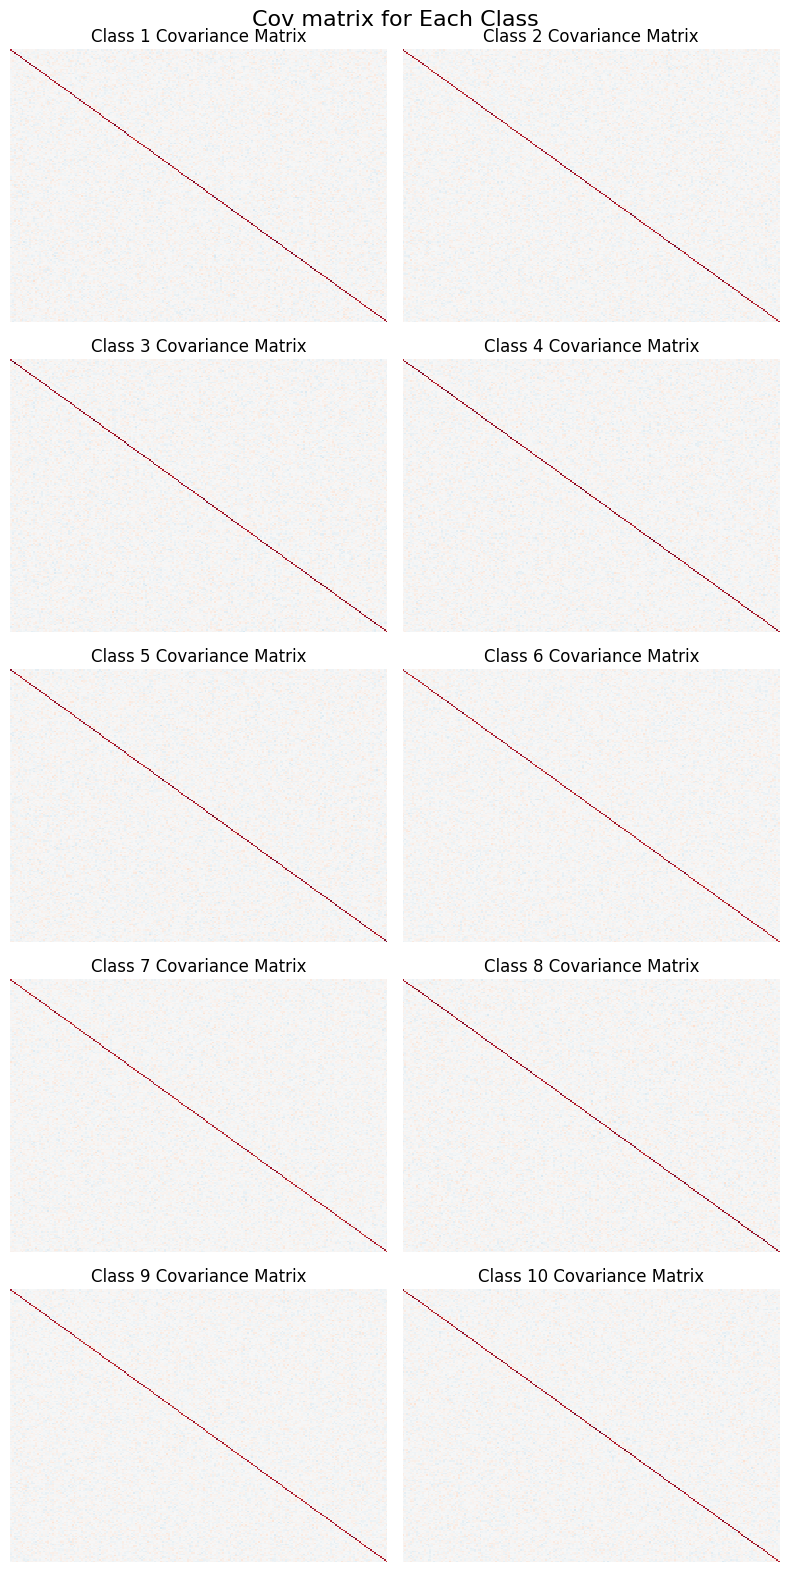

In [130]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_class_covariance(loader, dataset):
    images = dataset.images.numpy()
    labels = dataset.labels.numpy()
    
    class_means = {}
    class_covs = {}
    
    for class_id in range(10):
        class_samples = images[labels == class_id]
        class_flat = class_samples.reshape(class_samples.shape[0], -1)
        class_mean = class_flat.mean(axis=0)
        class_cov = np.cov(class_flat.T)
        
        class_means[class_id] = class_mean
        class_covs[class_id] = class_cov
    
    return class_means, class_covs

def visualize_class_histograms(dataset):
    images = dataset.images.numpy()
    labels = dataset.labels.numpy()
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    
    for class_id in range(10):
        row, col = class_id // 5, class_id % 5
        class_samples = images[labels == class_id]
        sample_idx = np.random.randint(0, len(class_samples))
        sample = class_samples[sample_idx, 0].flatten()
        
        axes[row, col].hist(sample, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
        axes[row, col].set_title(f'Class {class_id+1}')
        axes[row, col].set_xlabel('Pixel value')
        axes[row, col].set_ylabel('Frequency')
    
    plt.suptitle('Pixel value distribution for one sample from each class')
    plt.tight_layout()
    plt.show()


def visualize_covariance_matrices(class_covs, num_classes=10):
    fig, axes = plt.subplots(5, 2, figsize=(8, 16))
    for class_id in range(num_classes):
        row, col = class_id // 2, class_id % 2
        
        sns.heatmap(class_covs[class_id], 
                    ax=axes[row, col],
                    cmap='RdBu_r',
                    center=0,
                    cbar=False,
                    xticklabels=False,
                    yticklabels=False)
        
        axes[row, col].set_title(f'Class {class_id+1} Covariance Matrix')
    
    plt.suptitle('Cov matrix for Each Class', fontsize=16)
    plt.tight_layout()
    plt.show()

class_means, class_covs = compute_class_covariance(test_loader, test_dataset)
visualize_class_histograms(train_dataset)
visualize_covariance_matrices(class_covs)

#### 2- Mnist network

In [131]:
import torch
import torch.nn as nn
import torch.optim as optim

class FaceRecognitionCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(FaceRecognitionCNN, self).__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 1 * 1, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = FaceRecognitionCNN(num_classes=10)
total_params = count_parameters(model)
print(f'Model parameters: {total_params:,}')

Model parameters: 129,226


In [132]:
def train_model(model, train_loader, test_loader, epochs=30, lr=0.001):
    device = torch.device('mps' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    weight_decay_value = lr * 0.01
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay_value)
    
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []
    
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        correct_train = 0
        total_train = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        avg_train_loss = epoch_train_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        
        model.eval()
        epoch_test_loss = 0
        correct_test = 0
        total_test = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                epoch_test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
        
        avg_test_loss = epoch_test_loss / len(test_loader)
        test_acc = 100 * correct_test / total_test
        test_losses.append(avg_test_loss)
        test_accs.append(test_acc)
        
        print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {avg_test_loss:.4f} | Test Acc: {test_acc:.2f}%')
    
    return train_losses, test_losses, train_accs, test_accs

train_losses, test_losses, train_accs, test_accs = train_model(model, train_loader, test_loader, epochs=10, lr=0.001)

Epoch [1/10] | Train Loss: 0.7369 | Train Acc: 76.89% | Test Loss: 0.2761 | Test Acc: 91.67%
Epoch [2/10] | Train Loss: 0.1767 | Train Acc: 94.63% | Test Loss: 0.1792 | Test Acc: 94.15%
Epoch [3/10] | Train Loss: 0.0928 | Train Acc: 97.16% | Test Loss: 0.1691 | Test Acc: 94.08%
Epoch [4/10] | Train Loss: 0.0572 | Train Acc: 98.38% | Test Loss: 0.1740 | Test Acc: 94.22%
Epoch [5/10] | Train Loss: 0.0486 | Train Acc: 98.43% | Test Loss: 0.1866 | Test Acc: 94.12%
Epoch [6/10] | Train Loss: 0.0335 | Train Acc: 99.06% | Test Loss: 0.1337 | Test Acc: 96.03%
Epoch [7/10] | Train Loss: 0.0285 | Train Acc: 99.16% | Test Loss: 0.1834 | Test Acc: 94.40%
Epoch [8/10] | Train Loss: 0.0294 | Train Acc: 99.10% | Test Loss: 0.1598 | Test Acc: 95.30%
Epoch [9/10] | Train Loss: 0.0276 | Train Acc: 99.16% | Test Loss: 0.1535 | Test Acc: 95.28%
Epoch [10/10] | Train Loss: 0.0250 | Train Acc: 99.18% | Test Loss: 0.1677 | Test Acc: 95.22%


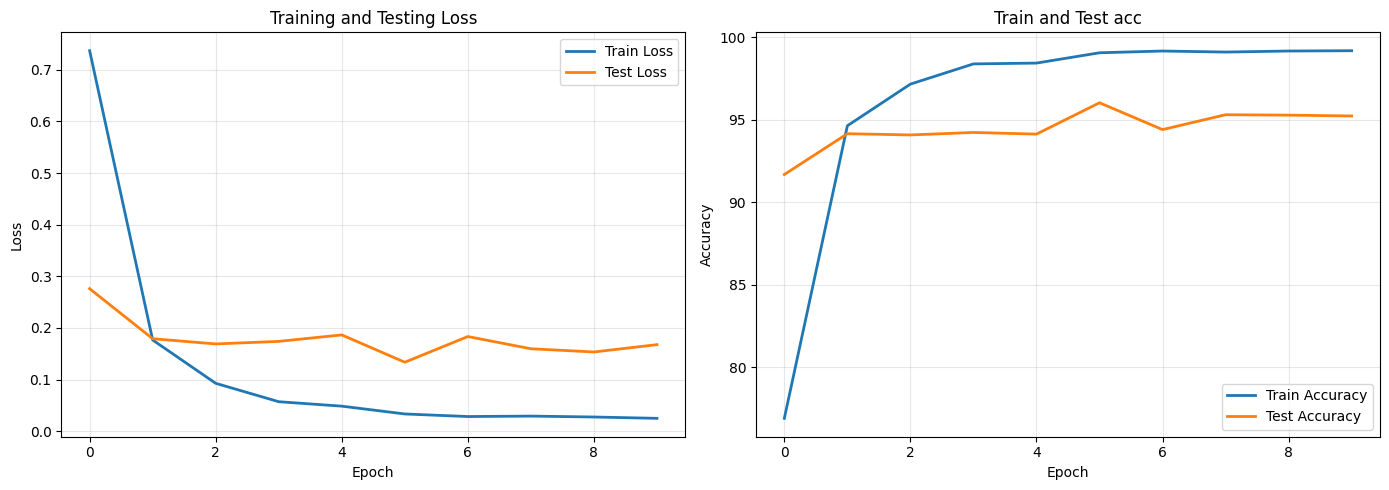

Test Accuracy: 95.22%


In [133]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(test_losses, label='Test Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Testing Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label='Train Accuracy', linewidth=2)
ax2.plot(test_accs, label='Test Accuracy', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Train and Test acc')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Test Accuracy: {test_accs[-1]:.2f}%')

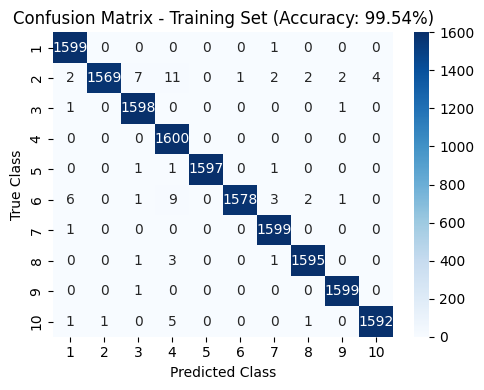

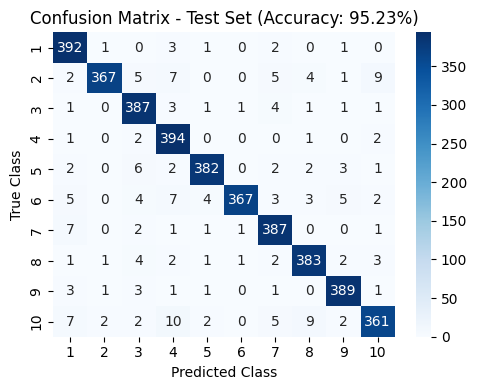

In [134]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(model, loader, dataset_name):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    accuracy = accuracy_score(all_labels, all_preds)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(1, 11), yticklabels=range(1, 11))
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.title(f'Confusion Matrix - {dataset_name} (Accuracy: {accuracy*100:.2f}%)')
    plt.tight_layout()
    plt.show()
    
    return cm, accuracy

train_cm, train_acc = plot_confusion_matrix(model, train_loader, 'Training Set')
test_cm, test_acc = plot_confusion_matrix(model, test_loader, 'Test Set')

In [135]:
print(f'count Parameters: {total_params:,}')
print(f'Optimizer: Adam with weight_decay = {0.001 * 0.01}')
print(f'Batch Size: {batch_size}')
print(f'Train acc: {train_accs[-1]:.2f}%')
print(f'Test acc: {test_accs[-1]:.2f}%')

count Parameters: 129,226
Optimizer: Adam with weight_decay = 1e-05
Batch Size: 64
Train acc: 99.18%
Test acc: 95.22%


#### 2- Base CNN model with softmax

In [144]:
class MNISTNetwork(nn.Module):
    def __init__(self, num_classes=10):
        super(MNISTNetwork, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 1 * 1, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
model = MNISTNetwork(num_classes=10)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')


Total parameters: 322,026


In [145]:
def train_model2(model, train_loader, test_loader, epochs=30, lr=0.001):
    device = torch.device('mps' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    weight_decay = lr * 0.01
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct_train = 0
        total_train = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        
        model.eval()
        test_loss = 0
        correct_test = 0
        total_test = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                test_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
        
        avg_test_loss = test_loss / len(test_loader)
        test_acc = 100 * correct_test / total_test
        test_losses.append(avg_test_loss)
        test_accs.append(test_acc)
        
        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:2d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {avg_test_loss:.4f} | Test Acc: {test_acc:.2f}%')
    
    return train_losses, test_losses, train_accs, test_accs

In [146]:
batch_size = 64
train_loader, test_loader, train_dataset, test_dataset = get_data(batch_size)

model = MNISTNetwork(num_classes=10)

train_losses, test_losses, train_accs, test_accs = train_model2(
    model, train_loader, test_loader, epochs=30, lr=0.001
)

Epoch  5/30 | Train Loss: 0.0608 | Train Acc: 98.18% | Test Loss: 0.1517 | Test Acc: 96.38%
Epoch 10/30 | Train Loss: 0.0447 | Train Acc: 98.74% | Test Loss: 0.2029 | Test Acc: 96.38%
Epoch 15/30 | Train Loss: 0.0378 | Train Acc: 98.98% | Test Loss: 0.1263 | Test Acc: 97.47%
Epoch 20/30 | Train Loss: 0.0497 | Train Acc: 98.75% | Test Loss: 0.2326 | Test Acc: 96.35%
Epoch 25/30 | Train Loss: 0.0314 | Train Acc: 99.30% | Test Loss: 0.1047 | Test Acc: 97.53%
Epoch 30/30 | Train Loss: 0.0202 | Train Acc: 99.46% | Test Loss: 0.1111 | Test Acc: 97.90%


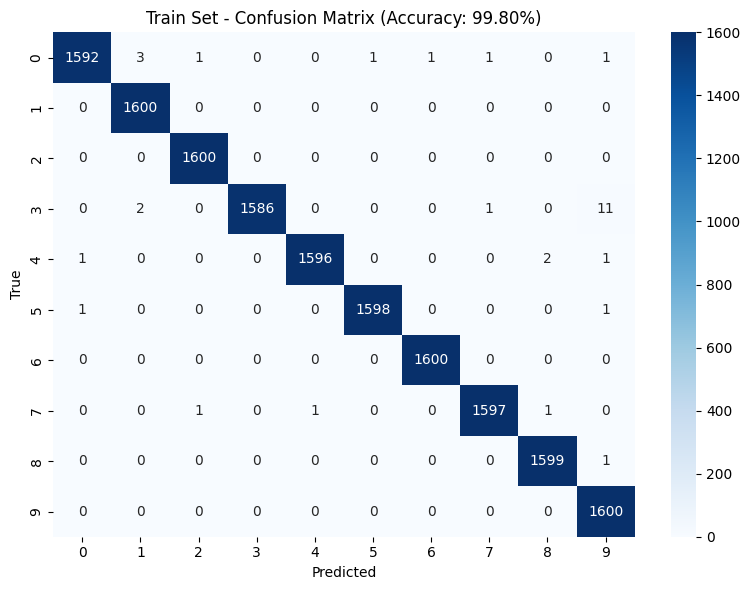

Train Accuracy: 99.80%


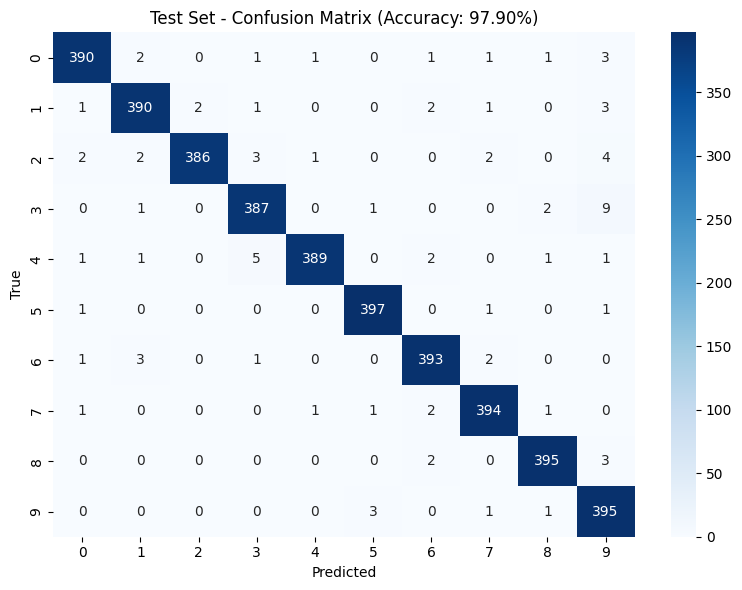

Test Accuracy: 97.90%


In [147]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

def evaluate_model(model, train_loader, test_loader):
    device = torch.device('mps' if torch.cuda.is_available() else 'cpu')
    model.eval()
    
    results = {}
    
    for name, loader in [('Train', train_loader), ('Test', test_loader)]:
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in loader:
                images = images.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.numpy())
        
        cm = confusion_matrix(all_labels, all_preds)
        acc = accuracy_score(all_labels, all_preds)
        results[name] = {'cm': cm, 'acc': acc}
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=range(10), yticklabels=range(10))
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title(f'{name} Set - Confusion Matrix (Accuracy: {acc*100:.2f}%)')
        plt.tight_layout()
        plt.show()
        
        print(f'{name} Accuracy: {acc*100:.2f}%')
    
    return results

results = evaluate_model(model, train_loader, test_loader)

In [ ]:
train_acc = results['Train']['acc'] * 100
test_acc = results['Test']['acc'] * 100
gap = train_acc - test_acc

print(f'Train Accuracy: {train_acc:.2f}%')
print(f'Test Accuracy: {test_acc:.2f}%')
print(f'Gap: {gap:.2f}%')

if gap > 5:
    print('Result: Overfitting detected - Model memorized training data')
elif gap < 0:
    print('Result: Underfitting detected - Model needs more capacity')
else:
    print('Result: Model is well balanced')

cm = results['Test']['cm']
for i in range(10):
    misclassified_as = []
    for j in range(10):
        if i != j and cm[i, j] > 0:
            misclassified_as.append((j, cm[i, j]))
    if misclassified_as:
        misclassified_as.sort(key=lambda x: x[1], reverse=True)
        top_confusion = misclassified_as[:3]
        print(f'Class {i} often confused with: {[c[0] for c in top_confusion]}')

=== Overfitting Analysis ===
Train Accuracy: 99.80%
Test Accuracy: 97.90%
Gap: 1.90%
Result: Model is well balanced

=== Class Confusion Analysis ===
Class 0 often confused with: [9, 1, 3]
Class 1 often confused with: [9, 2, 6]
Class 2 often confused with: [9, 3, 0]
Class 3 often confused with: [9, 8, 1]
Class 4 often confused with: [3, 6, 0]
Class 5 often confused with: [0, 7, 9]
Class 6 often confused with: [1, 7, 0]
Class 7 often confused with: [6, 0, 4]
Class 8 often confused with: [9, 6]
Class 9 often confused with: [5, 7, 8]


In [149]:
class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super(FeatureExtractor, self).__init__()
        self.features = model.features
        self.classifier_part = nn.Sequential(
            model.classifier[0],
            model.classifier[1],
            model.classifier[2],
            model.classifier[3],
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier_part(x)
        return x

def extract_features(model, loader):
    device = torch.device('mps' if torch.cuda.is_available() else 'cpu')
    feature_extractor = FeatureExtractor(model).to(device)
    feature_extractor.eval()
    
    all_features = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            features = feature_extractor(images)
            all_features.extend(features.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_features), np.array(all_labels)

print('Extracting features before softmax...')
features, labels = extract_features(model, test_loader)
print(f'Features shape: {features.shape}')
print(f'Labels shape: {labels.shape}')

Extracting features before softmax...
Features shape: (4000, 10)
Labels shape: (4000,)


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
features_2d = pca.fit_transform(features)

print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}')
print(f'Total variance explained: {sum(pca.explained_variance_ratio_):.2%}')

Variance explained by PC1: 37.74%
Variance explained by PC2: 17.20%
Total variance explained: 54.94%


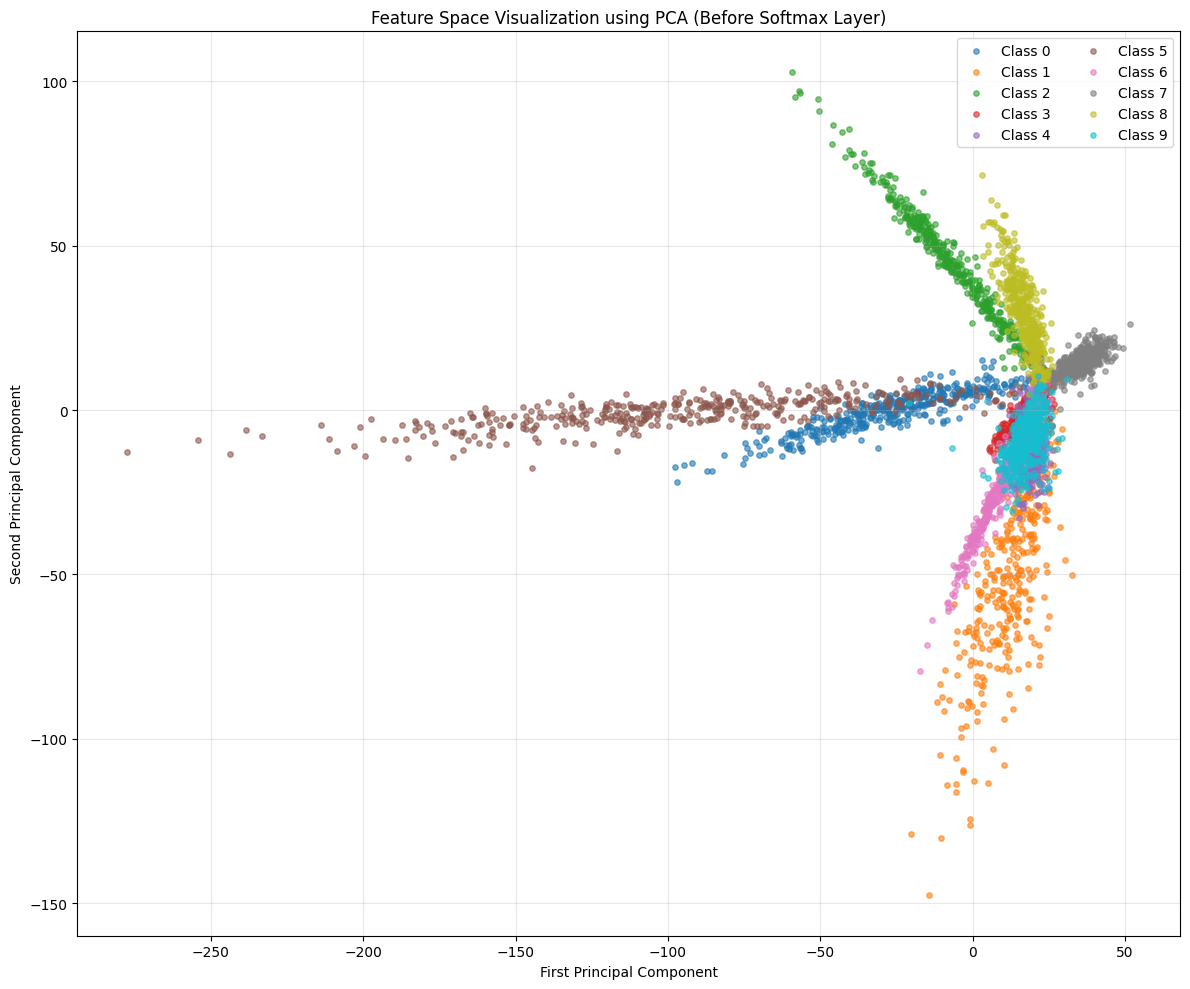

In [151]:
plt.figure(figsize=(12, 10))

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for class_id in range(10):
    mask = labels == class_id
    plt.scatter(features_2d[mask, 0], features_2d[mask, 1], 
                c=[colors[class_id]], label=f'Class {class_id}', 
                alpha=0.6, s=15)

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Feature Space Visualization using PCA (Before Softmax Layer)')
plt.legend(loc='best', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [152]:
print('=== Feature Space Analysis ===')

unique_classes = np.unique(labels)
class_centers = []
for class_id in unique_classes:
    mask = labels == class_id
    center = features_2d[mask].mean(axis=0)
    class_centers.append(center)
    
    intra_dist = np.mean(np.linalg.norm(features_2d[mask] - center, axis=1))
    print(f'Class {class_id}: center = ({center[0]:.2f}, {center[1]:.2f}), intra-class spread = {intra_dist:.2f}')

inter_distances = []
for i in range(len(class_centers)):
    for j in range(i+1, len(class_centers)):
        dist = np.linalg.norm(class_centers[i] - class_centers[j])
        inter_distances.append(dist)
        print(f'Distance between Class {i} and Class {j}: {dist:.2f}')

print(f'\nAverage inter-class distance: {np.mean(inter_distances):.2f}')
print(f'Average intra-class spread: {np.mean([np.linalg.norm(features_2d[labels==c] - features_2d[labels==c].mean(axis=0), axis=1).mean() for c in range(10)]):.2f}')

if np.mean(inter_distances) > np.mean([np.linalg.norm(features_2d[labels==c] - features_2d[labels==c].mean(axis=0), axis=1).mean() for c in range(10)]):
    print('Conclusion: Classes are well separated in feature space')
else:
    print('Conclusion: Significant overlap exists between classes')

=== Feature Space Analysis ===
Class 0: center = (-25.27, 0.08), intra-class spread = 19.89
Class 1: center = (13.12, -44.94), intra-class spread = 25.73
Class 2: center = (-5.79, 42.76), intra-class spread = 20.82
Class 3: center = (17.06, -0.22), intra-class spread = 5.79
Class 4: center = (18.99, -8.79), intra-class spread = 8.23
Class 5: center = (-95.79, -0.56), intra-class spread = 42.39
Class 6: center = (8.59, -23.14), intra-class spread = 13.64
Class 7: center = (35.10, 14.54), intra-class spread = 5.40
Class 8: center = (16.61, 29.60), intra-class spread = 10.60
Class 9: center = (17.38, -9.33), intra-class spread = 7.51
Distance between Class 0 and Class 1: 59.17
Distance between Class 0 and Class 2: 46.92
Distance between Class 0 and Class 3: 42.33
Distance between Class 0 and Class 4: 45.14
Distance between Class 0 and Class 5: 70.52
Distance between Class 0 and Class 6: 41.06
Distance between Class 0 and Class 7: 62.08
Distance between Class 0 and Class 8: 51.24
Distance 

#### 3-

In [153]:
class AngularMarginModel(nn.Module):
    def __init__(self, num_classes=10, embedding_size=128):
        super(AngularMarginModel, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        
        self.embedding = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 1 * 1, embedding_size),
            nn.BatchNorm1d(embedding_size),
        )
        
        self.fc = nn.Linear(embedding_size, num_classes, bias=False)
    
    def forward(self, x):
        x = self.features(x)
        embedding = self.embedding(x)
        
        embedding_norm = torch.nn.functional.normalize(embedding, p=2, dim=1)
        weight_norm = torch.nn.functional.normalize(self.fc.weight, p=2, dim=1)
        
        logits = torch.mm(embedding_norm, weight_norm.t())
        
        return logits, embedding_norm

model = AngularMarginModel(num_classes=10, embedding_size=128)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Total parameters: 304,480


In [154]:
class AngularMarginLoss(nn.Module):
    def __init__(self, margin=0.3, scale=30):
        super(AngularMarginLoss, self).__init__()
        self.margin = margin
        self.scale = scale
    
    def forward(self, logits, labels):
        batch_size = logits.size(0)
        
        one_hot = torch.zeros_like(logits)
        one_hot.scatter_(1, labels.unsqueeze(1), 1)
        
        cos_theta = logits
        cos_theta_m = cos_theta - self.margin * one_hot
        
        final_logits = self.scale * cos_theta_m
        loss = torch.nn.functional.cross_entropy(final_logits, labels)
        
        return loss

def train_angular_model(model, train_loader, test_loader, epochs=30, lr=0.001, margin=0.3, scale=30):
    device = torch.device('mps' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    weight_decay = lr * 0.01
    criterion = AngularMarginLoss(margin=margin, scale=scale)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        correct_train = 0
        total_train = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            logits, _ = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
        
        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        
        model.eval()
        test_loss = 0
        correct_test = 0
        total_test = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                logits, _ = model(images)
                loss = criterion(logits, labels)
                
                test_loss += loss.item()
                _, predicted = torch.max(logits, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()
        
        avg_test_loss = test_loss / len(test_loader)
        test_acc = 100 * correct_test / total_test
        test_losses.append(avg_test_loss)
        test_accs.append(test_acc)
        
        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:2d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {avg_test_loss:.4f} | Test Acc: {test_acc:.2f}%')
    
    return train_losses, test_losses, train_accs, test_accs

In [155]:
batch_size = 64
train_loader, test_loader, train_dataset, test_dataset = get_data(batch_size)

model_angular = AngularMarginModel(num_classes=10, embedding_size=128)

print('Training with Angular Margin Loss (margin=0.3, scale=30)...')
train_losses, test_losses, train_accs, test_accs = train_angular_model(
    model_angular, train_loader, test_loader, epochs=30, lr=0.001, margin=0.3, scale=30
)

print(f'\nFinal Test Accuracy: {test_accs[-1]:.2f}%')

Training with Angular Margin Loss (margin=0.3, scale=30)...
Epoch  5/30 | Train Loss: 0.1388 | Train Acc: 99.72% | Test Loss: 0.4911 | Test Acc: 98.08%
Epoch 10/30 | Train Loss: 0.0929 | Train Acc: 99.73% | Test Loss: 0.4113 | Test Acc: 98.22%
Epoch 15/30 | Train Loss: 0.0675 | Train Acc: 99.80% | Test Loss: 0.5281 | Test Acc: 97.90%
Epoch 20/30 | Train Loss: 0.0578 | Train Acc: 99.85% | Test Loss: 0.4124 | Test Acc: 98.25%
Epoch 25/30 | Train Loss: 0.0503 | Train Acc: 99.86% | Test Loss: 0.3622 | Test Acc: 98.42%
Epoch 30/30 | Train Loss: 0.0236 | Train Acc: 99.95% | Test Loss: 0.2768 | Test Acc: 98.78%

Final Test Accuracy: 98.78%


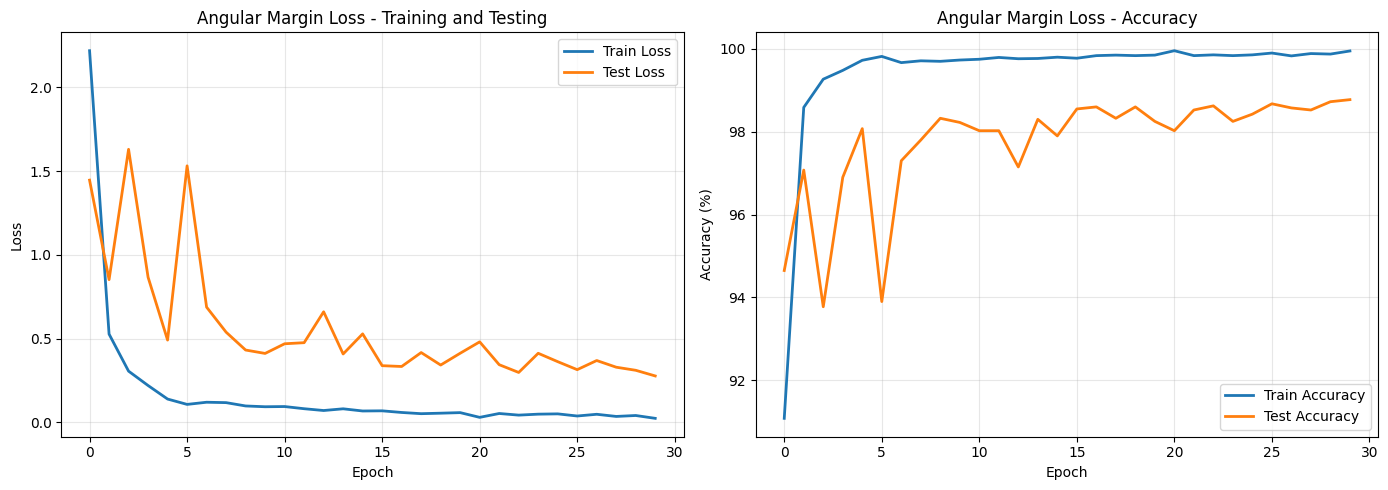

In [157]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(test_losses, label='Test Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Angular Margin Loss - Training and Testing')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, label='Train Accuracy', linewidth=2)
ax2.plot(test_accs, label='Test Accuracy', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Angular Margin Loss - Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [158]:
batch_sizes = [32, 64, 128]
margin_results = {}

for bs in batch_sizes:
    print(f'\n=== Training with batch_size = {bs} ===')
    train_loader, test_loader, _, _ = get_data(bs)
    
    model_temp = AngularMarginModel(num_classes=10, embedding_size=128)
    _, _, _, test_accs_temp = train_angular_model(
        model_temp, train_loader, test_loader, epochs=15, lr=0.001, margin=0.3, scale=30
    )
    
    margin_results[bs] = test_accs_temp[-1]
    print(f'Batch size {bs} -> Final test accuracy: {test_accs_temp[-1]:.2f}%')

print('\n=== Effect of Batch Size on Angular Margin Loss ===')
for bs, acc in margin_results.items():
    print(f'Batch size {bs}: {acc:.2f}%')

print('\nConclusion:')
print('- Smaller batch sizes often give better margins')
print('- Larger batch sizes train faster but may reduce margin effect')


=== Training with batch_size = 32 ===
Epoch  5/15 | Train Loss: 0.2841 | Train Acc: 99.05% | Test Loss: 0.4924 | Test Acc: 97.75%
Epoch 10/15 | Train Loss: 0.1285 | Train Acc: 99.59% | Test Loss: 0.4161 | Test Acc: 98.22%
Epoch 15/15 | Train Loss: 0.0936 | Train Acc: 99.70% | Test Loss: 0.4517 | Test Acc: 98.03%
Batch size 32 -> Final test accuracy: 98.03%

=== Training with batch_size = 64 ===
Epoch  5/15 | Train Loss: 0.1724 | Train Acc: 99.59% | Test Loss: 0.6260 | Test Acc: 97.85%
Epoch 10/15 | Train Loss: 0.0833 | Train Acc: 99.82% | Test Loss: 0.5289 | Test Acc: 97.72%
Epoch 15/15 | Train Loss: 0.0665 | Train Acc: 99.83% | Test Loss: 0.4851 | Test Acc: 98.03%
Batch size 64 -> Final test accuracy: 98.03%

=== Training with batch_size = 128 ===
Epoch  5/15 | Train Loss: 0.0961 | Train Acc: 99.86% | Test Loss: 0.7100 | Test Acc: 97.60%
Epoch 10/15 | Train Loss: 0.0537 | Train Acc: 99.91% | Test Loss: 0.4816 | Test Acc: 98.08%
Epoch 15/15 | Train Loss: 0.0555 | Train Acc: 99.88% | T

In [159]:
def extract_embeddings(model, loader):
    device = torch.device('mps' if torch.cuda.is_available() else 'cpu')
    model.eval()
    
    all_embeddings = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            _, embeddings = model(images)
            all_embeddings.extend(embeddings.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_embeddings), np.array(all_labels)

print('Extracting embeddings from Angular Margin Model...')
embeddings, emb_labels = extract_embeddings(model_angular, test_loader)
print(f'Embeddings shape: {embeddings.shape}')

Extracting embeddings from Angular Margin Model...
Embeddings shape: (4000, 128)


Variance explained by PC1: 14.99%
Variance explained by PC2: 13.88%


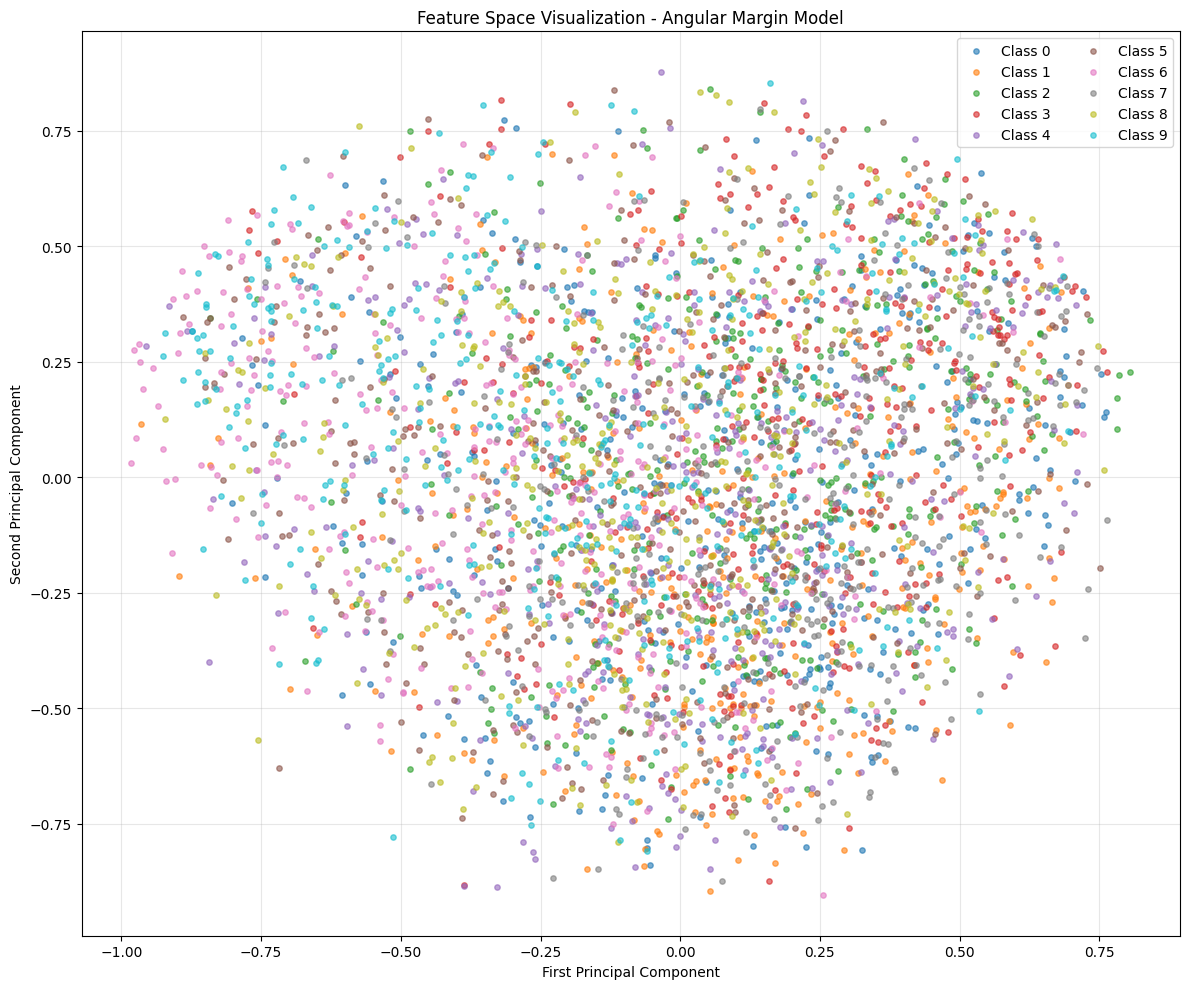

In [160]:
from sklearn.decomposition import PCA

pca_angular = PCA(n_components=2)
embeddings_2d = pca_angular.fit_transform(embeddings)

print(f'Variance explained by PC1: {pca_angular.explained_variance_ratio_[0]:.2%}')
print(f'Variance explained by PC2: {pca_angular.explained_variance_ratio_[1]:.2%}')

plt.figure(figsize=(12, 10))

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for class_id in range(10):
    mask = emb_labels == class_id
    plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1], 
                c=[colors[class_id]], label=f'Class {class_id}', 
                alpha=0.6, s=15)

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Feature Space Visualization - Angular Margin Model')
plt.legend(loc='best', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [161]:
print('=== Angular Margin Model Analysis ===')

class_centers_angular = []
for class_id in range(10):
    mask = emb_labels == class_id
    center = embeddings_2d[mask].mean(axis=0)
    class_centers_angular.append(center)
    intra_dist = np.mean(np.linalg.norm(embeddings_2d[mask] - center, axis=1))
    print(f'Class {class_id}: intra-class spread = {intra_dist:.2f}')

inter_distances_angular = []
for i in range(10):
    for j in range(i+1, 10):
        dist = np.linalg.norm(class_centers_angular[i] - class_centers_angular[j])
        inter_distances_angular.append(dist)

print(f'\nAverage inter-class distance: {np.mean(inter_distances_angular):.2f}')
print(f'Average intra-class spread: {np.mean([np.linalg.norm(embeddings_2d[emb_labels==c] - embeddings_2d[emb_labels==c].mean(axis=0), axis=1).mean() for c in range(10)]):.2f}')

print('\n=== Comparison with Softmax Model ===')
print('Note: Run the same analysis on your Softmax model and compare')
print('Expected: Angular margin model shows larger inter-class distances')

=== Angular Margin Model Analysis ===
Class 0: intra-class spread = 0.45
Class 1: intra-class spread = 0.45
Class 2: intra-class spread = 0.41
Class 3: intra-class spread = 0.44
Class 4: intra-class spread = 0.48
Class 5: intra-class spread = 0.47
Class 6: intra-class spread = 0.45
Class 7: intra-class spread = 0.45
Class 8: intra-class spread = 0.45
Class 9: intra-class spread = 0.47

Average inter-class distance: 0.20
Average intra-class spread: 0.45

=== Comparison with Softmax Model ===
Note: Run the same analysis on your Softmax model and compare
Expected: Angular margin model shows larger inter-class distances
